In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

anime_data = pd.read_csv("anime.csv")   
rating_data = pd.read_csv("rating.csv") 

print(anime_data.head())
print(rating_data.head())


   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
   user_id  anime_id  rating
0        1        20      -1
1        1        24      -1
2        1        79      -1
3        1       226      -1
4

In [6]:
anime_fulldata = pd.merge(anime_data,rating_data,on='anime_id',suffixes=['', '_user'])

anime_fulldata = anime_fulldata.rename(columns={'name': 'anime_title','rating_user': 'user_rating'})

anime_fulldata.head()


,anime_id,anime_title,genre,type,episodes,rating,members,user_id,user_rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,278,-1


In [7]:
anime_fulldata.isna().sum().sort_values(ascending=False)

genre          110
rating           6
type             4
anime_id         0
anime_title      0
episodes         0
members          0
user_id          0
user_rating      0
dtype: int64

In [8]:
anime_fulldata.describe().T

,count,mean,std,min,25%,50%,75%,max
anime_id,7813727.0,8909.045304,8883.922999,1.00,1240.00,6213.00,14093.00,34519.0
rating,7813721.0,7.653127,0.673029,1.67,7.27,7.68,8.13,9.5
members,7813727.0,178620.804981,188176.417152,29.00,44030.00,110470.00,244268.00,1013917.0
user_id,7813727.0,36727.954737,20997.950759,1.00,18974.00,36791.00,54757.00,73516.0
user_rating,7813727.0,6.144036,3.727796,-1.00,6.00,7.00,9.00,10.0


In [9]:
genres = anime_fulldata['genre'].dropna().str.split(', ').explode()
genres.value_counts().head(20)

genre
Comedy           3908786
Action           3263394
Romance          2487902
Drama            2101320
Fantasy          2021337
Supernatural     1964113
School           1884897
Shounen          1882227
Adventure        1695966
Sci-Fi           1613129
Slice of Life    1098829
Ecchi             954750
Mystery           899054
Super Power       781064
Magic             769540
Harem             760586
Seinen            752464
Psychological     567722
Mecha             566502
Shoujo            493460
Name: count, dtype: int64

In [10]:
anime_fulldata['anime_title'].value_counts().head(10)


anime_title
Death Note                          39340
Sword Art Online                    30583
Shingeki no Kyojin                  29584
Code Geass: Hangyaku no Lelouch     27718
Elfen Lied                          27506
Angel Beats!                        27183
Naruto                              25925
Fullmetal Alchemist                 25032
Fullmetal Alchemist: Brotherhood    24574
Toradora!                           24283
Name: count, dtype: int64

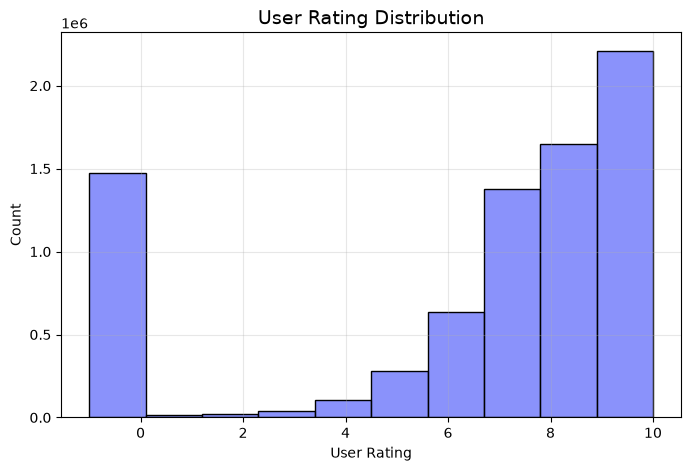

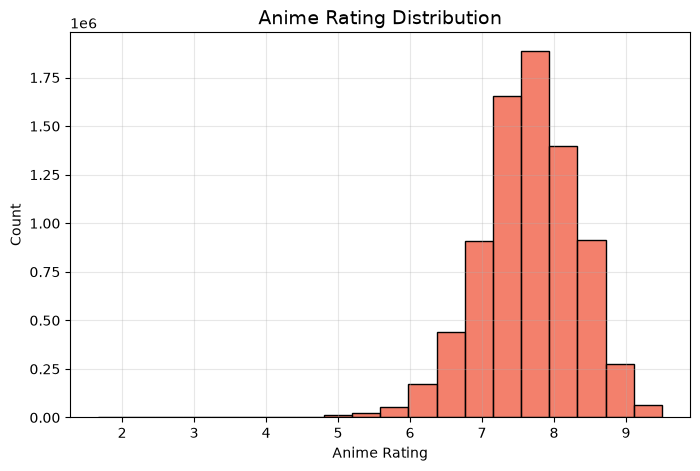

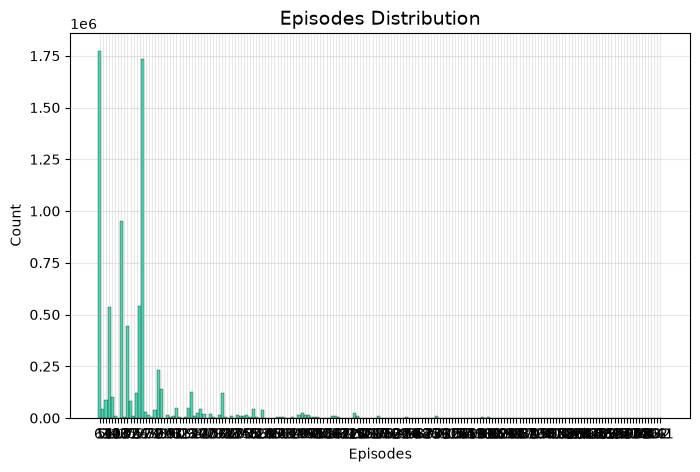

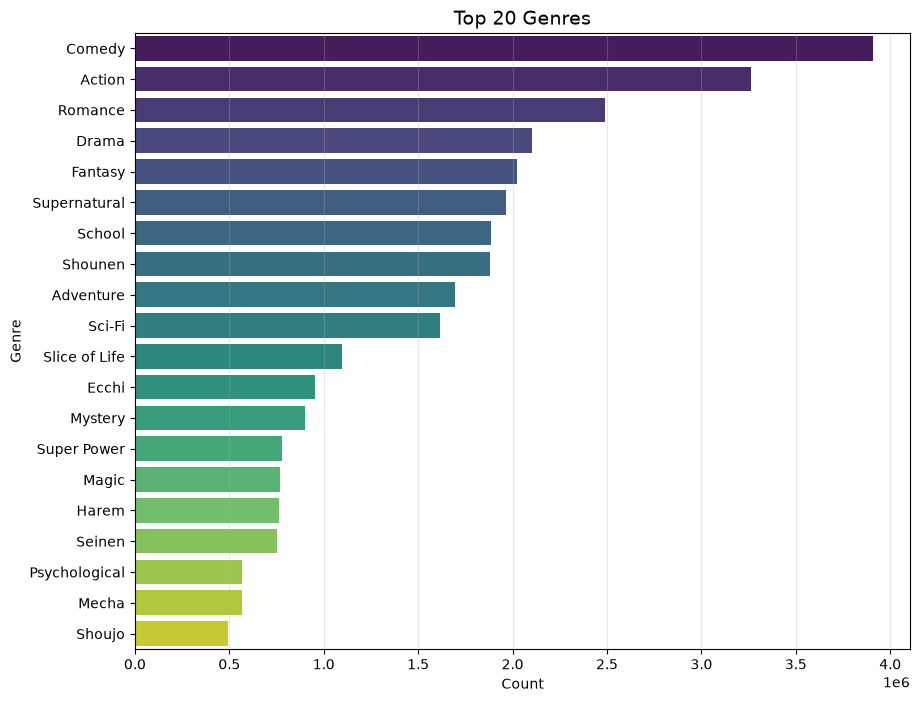

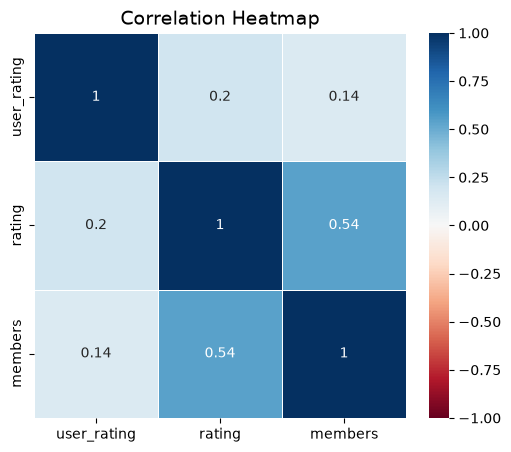

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=anime_fulldata,
    x="user_rating",
    bins=10,
    color="#636EFA",
    kde=False
)

plt.title("User Rating Distribution", fontsize=14)
plt.xlabel("User Rating")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(
    data=anime_fulldata,
    x="rating",
    bins=20,
    color="#EF553B",
    kde=False
)

plt.title("Anime Rating Distribution", fontsize=14)
plt.xlabel("Anime Rating")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(
    data=anime_fulldata,
    x="episodes",
    bins=30,
    color="#00CC96",
    kde=False
)

plt.title("Episodes Distribution", fontsize=14)
plt.xlabel("Episodes")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

genre_counts = genres.value_counts().reset_index()
genre_counts.columns = ['genre', 'count']
top20 = genre_counts.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top20,
    y='genre',
    x='count',
    hue='genre',        # required in seaborn >= 0.14
    palette='viridis',
    legend=False        # hide legend since hue = genre
)

plt.title("Top 20 Genres", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Genre")

plt.grid(axis='x', alpha=0.3)
plt.show()


# Compute correlation
corr = anime_fulldata[['user_rating', 'rating', 'members']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()


In [20]:
mean_user_rating = anime_fulldata.groupby('anime_id')['user_rating'].mean().reset_index()
mean_user_rating.rename(columns={'user_rating': 'user_mean_rating'}, inplace=True)

anime_meta = anime_data.merge(mean_user_rating, on='anime_id', how='left')
anime_meta['user_mean_rating'] = anime_meta['user_mean_rating'].fillna(anime_meta['rating'])
anime_meta['genre'] = anime_meta['genre'].fillna('').astype(str)
anime_meta['type'] = anime_meta['type'].fillna('').astype(str)

anime_meta['user_mean_rating'] = anime_meta['user_mean_rating'].fillna(anime_meta['rating'])
anime_meta['user_mean_rating'] = anime_meta['user_mean_rating'].fillna(0).astype(str)
anime_meta['genre'] = anime_meta['genre'].fillna('')
anime_meta['type'] = anime_meta['type'].fillna('')


In [21]:
anime_meta['text_features'] = (
    anime_meta['genre'] + ' ' +
    anime_meta['type'] + ' ' +
    anime_meta['user_mean_rating'].astype(str)
)



In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anime_meta['text_features'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(anime_meta.index, index=anime_meta['name']).drop_duplicates()
anime_meta['text_features'] = anime_meta['text_features'].fillna('')


In [24]:
def recommend(title, top_n=10):
    if title not in indices.index:
        print("Anime not found.")
        return pd.DataFrame()
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    anime_indices = [i[0] for i in sim_scores]
    return anime_meta.loc[
        anime_indices,
        ['anime_id','name','genre','type','rating','user_mean_rating','episodes','members']
    ]


In [25]:
recommend("Kimi no Na wa.", 10)


,anime_id,name,genre,type,rating,user_mean_rating,episodes,members
11082,33036,Suki ni Naru Sono Shunkan wo.: Kokuhaku Jikkou...,"Comedy, Drama, Romance, School",Movie,NaN,0.0,1,10668
11061,32262,Renai Boukun,"Comedy, Romance, School, Supernatural",TV,NaN,0.0,Unknown,4558
10123,29637,Samurai,"Drama, Romance",Movie,3.58,2.5,1,111
6160,2179,Tokimeki Memorial: Forever With You,"Drama, Romance, School",OVA,6.24,4.0,2,1734
11030,34106,Kyoukai no Rinne (TV) 3rd Season,"Comedy, Romance, School, Shounen, Supernatural",TV,NaN,0.0,Unknown,3628
4858,10723,Sojunghan Nal-ui Kkum,"Comedy, Drama, Romance",Movie,6.62,4.4,1,904
5925,1552,Hiatari Ryoukou! Yume no Naka ni Kimi ga Ita,"Comedy, Drama, Romance",Movie,6.31,3.5,1,399
8656,9351,Geunyeoneun Yeppeotda,"Comedy, Drama, Romance",Movie,6.65,-1.0,1,141
11035,32900,Mahouka Koukou no Rettousei Movie: Hoshi wo Yo...,"Action, Magic, Romance, School, Sci-Fi, Supern...",Movie,NaN,0.0,1,13884
9348,26043,Kurumiwari Ningyou (2014),"Drama, Fantasy, Romance",Movie,7.00,-1.0,1,136


In [26]:
recommend("Fullmetal Alchemist: Brotherhood", 10)

,anime_id,name,genre,type,rating,user_mean_rating,episodes,members
10953,28833,Chain Chronicle: Haecceitas no Hikari,"Action, Adventure, Fantasy, Magic, Shounen",TV,NaN,0.0,12,5678
3371,7109,Gyouten Ningen Batsealer,"Action, Adventure, Fantasy, Magic",TV,7.01,2.0,52,201
11107,32615,Youjo Senki,"Magic, Military",TV,NaN,0.0,Unknown,6652
4445,7364,Dragon Quest: Dai no Daibouken Buchiyabure!! S...,"Action, Adventure, Fantasy, Magic, Shounen",Movie,6.72,4.0,1,736
9529,18311,Meoteoldosa,"Action, Adventure, Fantasy, Magic, Shounen",Movie,5.89,-1.0,1,71
9531,18329,Meoteoldosawa Ttomae,"Action, Adventure, Fantasy, Magic, Shounen",Movie,5.38,-1.0,1,66
10954,33729,Chain Chronicle: Haecceitas no Hikari Part 2,"Action, Adventure, Fantasy, Magic, Shounen",Movie,NaN,0.0,1,2069
10955,33730,Chain Chronicle: Haecceitas no Hikari Part 3,"Action, Adventure, Fantasy, Magic, Shounen",Movie,NaN,0.0,1,1861
9259,18321,Kkomaeosa Ttori,"Action, Adventure, Drama, Fantasy, Historical,...",Movie,4.50,-1.0,1,59
10977,30778,Fairy Tail Movie 2,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",Movie,NaN,0.0,1,16446
